##

See how changing GM.fitting with in paper used standard settings changes?!

- normalize (z-score)
- kernel = 'cosine' (e.g. autism paper)/ 'normalized_angle' - Serio/Wang
- 

In [2]:

import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

dataset ='dnumrisk' #'smile1'#
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'
subList = [f'{int(sub):02d}' for sub in range(1, 67)]

target_folder = op.join(bids_folder,'derivatives','gradients.tryParams.36P')

In [4]:
alignRef = 'tanH'
kernel = 'normalized_angle' # 
ztransf = False
specification = f'kernel-{kernel}_ztransf-{ztransf}'

n_gradients = 3
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm =  op.join(target_folder,f'sub-{sub}')
    fn = op.join(source_folder_gm,f'sub-{sub}_g-aligned-{alignRef}_{specification}.npy')

    gm_aligned = np.load(fn)
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])

In [7]:
# add group info
bids_folder_orig = '/mnt_03/ds-dnumrisk' 
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()

dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms_aligned[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df = gradient_df.join(group_list).set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')

In [9]:
grad_variance = df_gms.std(axis=1).to_frame(name='grad_std')
grad_minmaxdiff = (df_gms.max(axis=1) - df_gms.min(axis=1)).to_frame(name='grad_minmaxdiff')

grad_stats = pd.concat([grad_variance, grad_minmaxdiff], axis=1)


grad_std - not normal distribution (reject H0)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


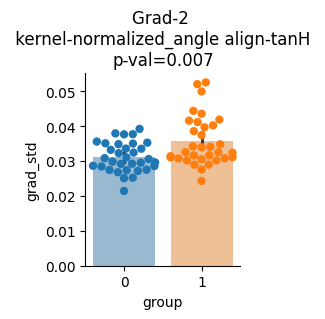

In [70]:
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
import seaborn as sns

alpha = 0.05

n_grad = 2
y_var =  'grad_std'#'grad_minmaxdiff' #
tmp = grad_stats.xs(n_grad, level='n_gradient')#.drop(64)

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
axes.set(title=f'Grad-{n_grad} \n kernel-{kernel} align-{alignRef} \np-val={stats.pvalue:.3f}',
    ylabel=y_var, xlabel='group')#,ylim=[0,15])
sns.despine()

In [14]:
from utils import get_NPC_mask, get_basic_mask

nprf_r2 = get_NPC_mask()
mask, labeling_noParcel = get_basic_mask()

np.shape(nprf_r2)

(20484,)

In [60]:
n_grad = 2
g1 = np.array(gms_aligned[f'g{n_grad}']).T # n_vertices x n_subjects

# get the gradient loadings of the nodes of the ROI, for each subject (shape: number of nodes in network x N)
G1_net = g1[nprf_r2]

centroid_cog_net = np.nanmedian(G1_net, axis=0)  #np.median(G1_net, axis=0)  
dist_nodes_to_centroid = G1_net - centroid_cog_net  # shape: number of nodes in network x N

NPC_dispersion = np.nanmean((dist_nodes_to_centroid**2), axis = 0) 

df = pd.DataFrame(np.array([NPC_dispersion, centroid_cog_net]).T, index=sub_array, columns=['NPC_dispersion', 'NPC_centroid'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)
#df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}_confspec-{confspec}.csv'))

df =  df.sort_index(level='subject')

In [68]:
# 2D dispersion measure
n_grad = 'both 2D'

g1 = np.array(gms_aligned[f'g1']).T
g2 = np.array(gms_aligned[f'g2']).T

G1_net = g1[nprf_r2]
G2_net = g2[nprf_r2]
G_net = np.stack([G1_net, G2_net], axis=-1)  # shape: number of nodes in network x N x 2

centroid_cog_net = np.nanmedian(G_net, axis=0)  # shape: N x 2

# Compute the 2D Euclidean distance between each node and the centroid for each subject
dist_nodes_to_centroid = G_net - centroid_cog_net  # shape: number of nodes in network x N x 2
squared_distances = np.sum(dist_nodes_to_centroid**2, axis=-1)  # sum squares across 2D (last axis), shape: number of nodes in network x N

# Compute the within-network dispersion as the mean squared distance
NPC_2d_dispersion =  np.nanmean(squared_distances, axis=0)  # shape: N

df = pd.DataFrame(NPC_2d_dispersion.T, index=sub_array, columns=['NPC_2D_dispersion'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)
#n_grad = 'both2D'
#df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}_confspec-{confspec}.csv'))



NPC_2D_dispersion - not normal distribution (reject H0)
MannwhitneyuResult(statistic=313.0, pvalue=0.003051998009491109)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


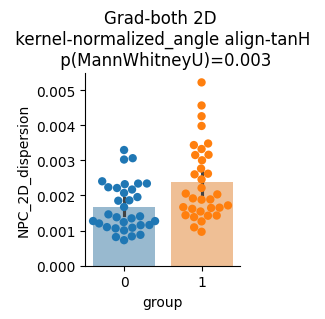

In [69]:
y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 
#df.loc[df[y_var].idxmax()]
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import normaltest
alpha = 0.05 # threshold for normality

y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 

#max_index = df[y_var].idxmax() # sub-06 weird... 
#tmp = df.drop(index=max_index)
#tmp = tmp.drop(index=tmp[y_var].idxmax())
#tmp = tmp.drop(index=tmp[y_var].idxmax())
tmp = df.copy()

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
        test_name = 't-test'
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
        test_name = 'MannWhitneyU'
axes.set(title=f'Grad-{n_grad} \n kernel-{kernel} align-{alignRef} \n p({test_name})={stats.pvalue:.3f}',ylabel=y_var, xlabel='group') #,ylim=[0,30])
sns.despine()

print(stats)

## Mean eccentricity  of different networks ?!

take the mean eccentricity of the network anchors: visual, somato-motot & default!

In [74]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]

In [71]:
fn_target_labels_caNets = op.join(bids_folder,'derivatives','networks_infomap_full', f'sub-average_consensusMapping_confspec-36Pscrub3BPfilter.npy') # mapped to ColeAnticevic nets
caNets_fsav5_mapping = np.load(fn_target_labels_caNets)

atlas_spec = 'own_av_netAtlas'

In [75]:
nets_of_interest = [2, 3, 9]  # visual, somato-motor, default

df_eccentricities = []

for n_network in nets_of_interest:
    net_mask = np.where(caNets_fsav5_mapping == (n_network))[0]
    g1 = np.array(gms_aligned[f'g1']).T[net_mask]
    g2 = np.array(gms_aligned[f'g2']).T[net_mask]
    g3 = np.array(gms_aligned[f'g3']).T[net_mask]

    eccentricities = np.sqrt(g1**2 + g2**2) # + g3**2)
    df_eccentricities.append(pd.DataFrame(np.nanmean(eccentricities, axis=0), index=sub_array, columns=[CAatlas_names.loc[n_network]['Network Name']]))
 
df_eccentricities = pd.concat(df_eccentricities, axis=1)
df_eccentricities.index.name = 'subject'
df_eccentricities = df_eccentricities.join(group_list, on='subject').set_index('group',append=True)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Visual2 - not normal distribution (reject H0)
MannwhitneyuResult(statistic=345.0, pvalue=0.0107085406515169)
Somatomotor - not normal distribution (reject H0)
MannwhitneyuResult(statistic=517.0, pvalue=0.7291468946128284)
Default - normal distribution (fail to reject H0)
TtestResult(statistic=-0.6127512477636077, pvalue=0.5422169280396849, df=63.85801574976692)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


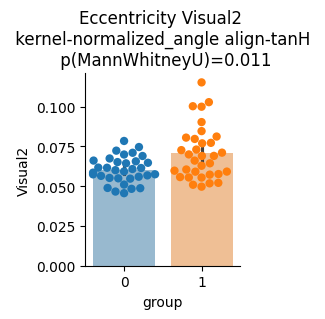

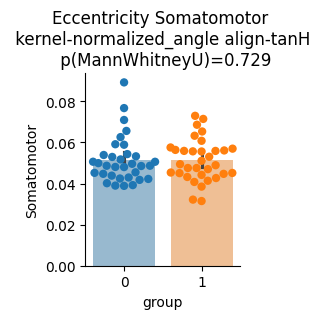

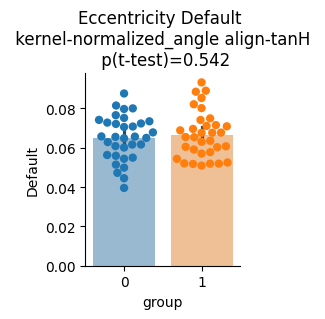

In [76]:
tmp = df_eccentricities.copy()

for y_var in df_eccentricities.columns:
        figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
        sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
        sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
        _, pval_normal = normaltest(tmp[y_var])
        if pval_normal > alpha:
                print(f'{y_var} - normal distribution (fail to reject H0)')
                stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
                test_name = 't-test'
        else: # non parametric test
                print(f'{y_var} - not normal distribution (reject H0)')    
                stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
                test_name = 'MannWhitneyU'
        axes.set(title=f'Eccentricity {y_var} \n kernel-{kernel} align-{alignRef} \n p({test_name})={stats.pvalue:.3f}',ylabel=y_var, xlabel='group') #,ylim=[0,30])
        sns.despine()

        print(stats)

# Prep GM code

In [3]:
sub = 'All'
target_dir = op.join(target_folder,f'sub-{sub}')
alignRef = 'tanH'
kernel = 'cosine'
ztransf = False
specification = f'kernel-{kernel}_ztransf-{ztransf}'
 
fn = op.join(target_dir,f'sub-{sub}_g-aligned-{alignRef}_{specification}.npy')
fn = op.join(target_dir,f'sub-{sub}_gradients_kernel-{kernel}_ztransf-{ztransf}_avMethod-{alignRef}.npy') # sub-All_gradients_kernel-normalized_angle_ztransf-False_avMethod-tanH.npy
grad = np.load(fn)

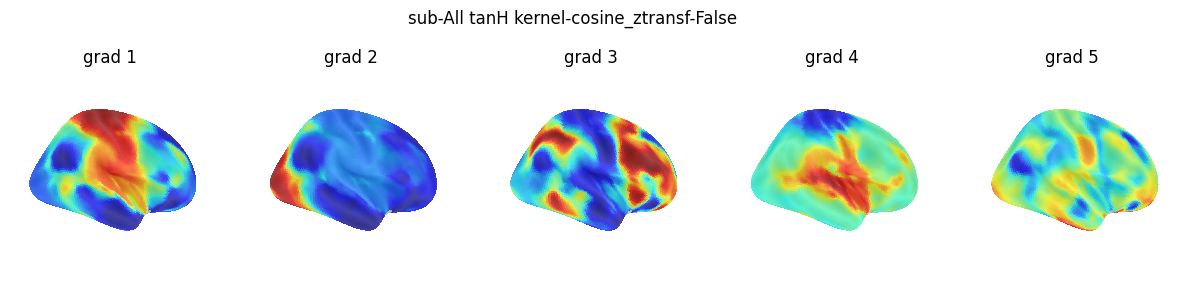

In [4]:
from utils import plot_grads

plot_grads(grad, sub, alignRef, specification)

In [ ]:
alignRef = 'tanH'

fn = f'sub-All_ses-1_task-magjudge_gradients_kernel-None_ztransf-False_avMethod-{alignRef}.npy'
ref_grad = op.join(target_folder,fn)
grad_ref = np.load(ref_grad)

### fit gradients dParams

In [11]:
sub = '01'
ses = '1'
task = 'magjudge'
confspec ='36Pscrub3BPfilterrunFD104-6runs'
key = f'.{confspec}'

kernel = None #'cosine'  #'normalized_angle'  #

target_dir = op.join(bids_folder, 'derivatives', f'gradients{key}', f'sub-{sub}')
if not op.exists(target_dir):
    os.makedirs(target_dir)

cm_fn = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo', f'sub-{sub}_ses-{ses}_task-magjudge_confspec-{confspec}_CM-unfiltered.npy')
cm = np.load(cm_fn)

In [7]:
print('Applying CC-mask for kernel=None')
cm_confspec = f'36Pscrub3BPfilterrunFD104'
cc_mask_file = op.join(op.join(bids_folder, 'derivatives', f'gradients.{cm_confspec}', f'sub-{sub}'), f'sub-{sub}_cc-mask_space-fsaverag5.npy')
mask_cc = np.load(cc_mask_file)
mask[mask == True] = mask_cc
cm = cm[mask_cc, :][:, mask_cc]

Applying CC-mask for kernel=None


In [13]:
alignRef = '-tanH'

ref_grad = op.join(bids_folder, 'derivatives', f'gradients.tryParams.36P','sub-All', f'sub-All_gradients_kernel-{kernel}_ztransf-False_avMethod-tanH.npy')
grad_ref = np.load(ref_grad)
grad_ref_fil = grad_ref[:,mask].T  # only use nodes in mask

In [14]:
ztransf = True
cm_ztransf = np.arctanh(cm)

/tmp/ipykernel_4184501/463754359.py:2: RuntimeWarning: divide by zero encountered in arctanh
  cm_ztransf = np.arctanh(cm)


In [ ]:
np.nan

In [16]:
n_components = 10
gm = GradientMaps(n_components=n_components, alignment='procrustes', kernel=kernel, approach='dm', random_state=0) 
gm.fit(cm_ztransf,reference=grad_ref_fil)

ValueError: Affinity matrix contains NaN or Inf values. Common causes of this include NaNs/Infs or rows of zeros in the input matrix.

### Diagnostic checks for NaN/Inf in affinity matrix

In [ ]:
# Check for NaN and Inf values in the correlation matrix
print("=== Checking cm_ztransf (transformed correlation matrix) ===")
print(f"Shape: {cm_ztransf.shape}")
print(f"Contains NaN: {np.isnan(cm_ztransf).any()}")
print(f"Number of NaN values: {np.isnan(cm_ztransf).sum()}")
print(f"Contains Inf: {np.isinf(cm_ztransf).any()}")
print(f"Number of Inf values: {np.isinf(cm_ztransf).sum()}")
print(f"Min value: {np.nanmin(cm_ztransf)}")
print(f"Max value: {np.nanmax(cm_ztransf)}")
print()

# Check the original correlation matrix before transformation
print("=== Checking original cm (before arctanh) ===")
print(f"Shape: {cm.shape}")
print(f"Contains NaN: {np.isnan(cm).any()}")
print(f"Number of NaN values: {np.isnan(cm).sum()}")
print(f"Min value: {np.nanmin(cm)}")
print(f"Max value: {np.nanmax(cm)}")
print(f"Values equal to 1.0: {(cm == 1.0).sum()}")
print(f"Values equal to -1.0: {(cm == -1.0).sum()}")
print(f"Values > 1.0: {(cm > 1.0).sum()}")
print(f"Values < -1.0: {(cm < -1.0).sum()}")
print()

# Check for rows with all zeros or all NaNs
print("=== Checking for problematic rows ===")
row_sums = np.nansum(np.abs(cm_ztransf), axis=1)
zero_rows = np.where(row_sums == 0)[0]
print(f"Rows with all zeros: {len(zero_rows)}")
if len(zero_rows) > 0 and len(zero_rows) < 20:
    print(f"Zero row indices: {zero_rows}")

all_nan_rows = np.where(np.all(np.isnan(cm_ztransf), axis=1))[0]
print(f"Rows with all NaNs: {len(all_nan_rows)}")
if len(all_nan_rows) > 0 and len(all_nan_rows) < 20:
    print(f"All-NaN row indices: {all_nan_rows}")

### Fix: Handle values at correlation boundaries before arctanh transformation

In [ ]:
# Fix the issue: clip values to valid range for arctanh
# arctanh is only defined for values in (-1, 1), not including -1 or 1
# Values of exactly 1.0 or -1.0 will produce Inf

# Option 1: Clip values to a safe range (slightly less than 1)
epsilon = 1e-6
cm_clipped = np.clip(cm, -1 + epsilon, 1 - epsilon)
cm_ztransf_fixed = np.arctanh(cm_clipped)

print("After clipping and transformation:")
print(f"Contains NaN: {np.isnan(cm_ztransf_fixed).any()}")
print(f"Contains Inf: {np.isinf(cm_ztransf_fixed).any()}")
print(f"Min value: {np.nanmin(cm_ztransf_fixed)}")
print(f"Max value: {np.nanmax(cm_ztransf_fixed)}")

In [ ]:
# save results
specification = f'kernel-{kernel}_ztransf-{ztransf}'
np.save(op.join(target_dir,f'sub-{sub}_lambdas_{specification}.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_gradients_{specification}.npy'), grad) # save all together
gm_ = gm.aligned_.T
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_g-aligned{alignRef}_{specification}.npy'), grad) # save all together

## Average

In [ ]:
# load in average CM and reference gradients
transform_spec = 'tan-hyperbolic' #'_FisherZ' #
confspec= '36Pscrub3BPfilterrunFD104' 
source_folder = op.join(bids_folder,'derivatives','correlation_matrices.tryNoHalo')

av_cm_transf = np.load(op.join(source_folder,f'cm_av_ses-1_fsav5_unfiltered_confspec-{confspec}{transform_spec}.npy'))

bids_folder_ref = f'/mnt_03/ds-dnumrisk'
g_ref = np.load(op.join(bids_folder_ref,'derivatives', 'gradients','reference_gradients_margulies16_space-fsaverage5_N-10.npy'))
from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
g_ref_fil = g_ref[:,mask].T  # np.shape(g_ref) = (10,20484)

In [ ]:
sub = 'All'
target_dir = op.join(bids_folder,'derivatives','gradients.tryParams.36P', f'sub-{sub}')
os.makedirs(target_dir, exist_ok=True)

kernel ='normalized_angle'  # with cosine kernel needs > 60 mins!  None #'cosine'  #
ztransf = True
avMethod = 'tanH'

if ztransf:
    cm = np.arctanh(av_cm_transf) 
else:
    cm = av_cm_transf

# fit gradients
import time
start_time = time.time()
gm = GradientMaps(n_components=10, alignment='procrustes', kernel=kernel, approach='dm', random_state=0)
gm.fit(cm, reference=g_ref_fil)
elapsed_time = time.time() - start_time
print(f"GM fitting Execution time: {elapsed_time/60:.2f} minutes ({elapsed_time:.2f} seconds)")

# save
specification = f'kernel-{kernel}_ztransf-{ztransf}_avMethod-{avMethod}'
np.save(op.join(target_dir,f'sub-{sub}_lambdas_{specification}.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * 10
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_gradients_{specification}.npy'), grad) # save all together
gm_ = gm.aligned_.T
grad = [None] * 10
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_g-aligned-marg_{specification}.npy'), grad) # save all together